In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import timedelta
import yfinance as yf
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import pickl


In [3]:
tsla_data = yf.download("TSLA", start="2015-01-01", end="2023-12-31")
tsla_data = tsla_data[['Close']]  # Keep only the 'Close' price


[*********************100%***********************]  1 of 1 completed


In [7]:
model = ARIMA(tsla_data['Close'], order=(2, 1, 2))
fitted_model = model.fit()

/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [8]:
# Forecasting for the next 252 days
forecast = fitted_model.get_forecast(steps=252)
forecast_values = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

# Adding dates to the forecast index
forecast_dates = pd.date_range(start=tsla_data.index[-1], periods=252 + 1, freq='B')[1:]
forecast_values.index = forecast_dates
confidence_intervals.index = forecast_dates


/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


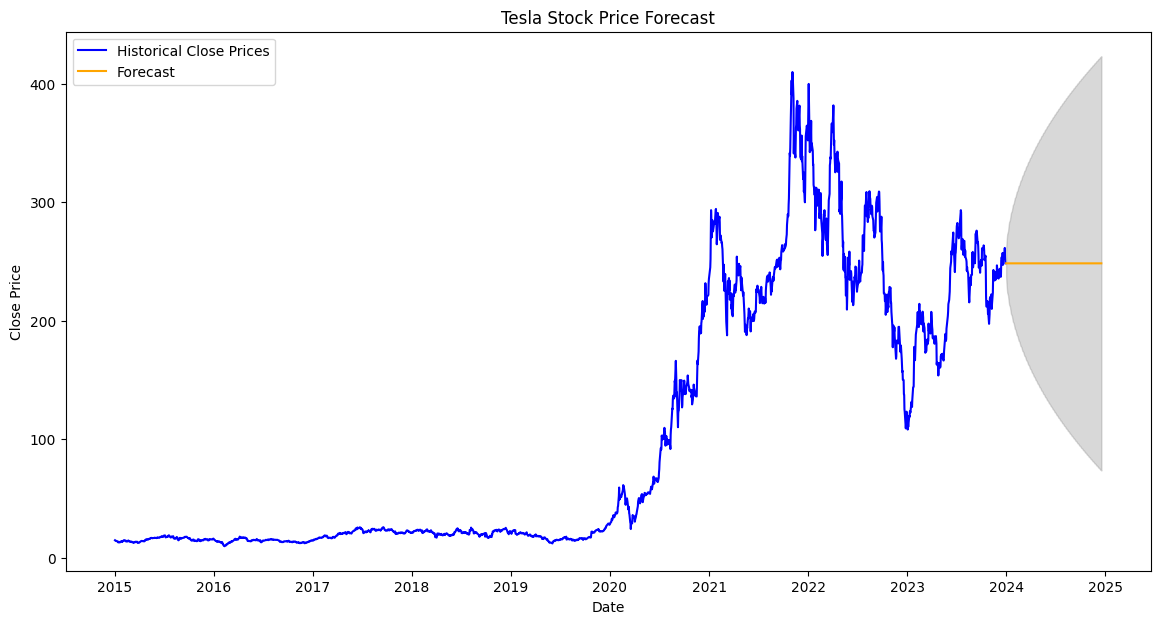

In [9]:
# Plot historical data
plt.figure(figsize=(14, 7))
plt.plot(tsla_data['Close'], label='Historical Close Prices', color='blue')

# Plot forecast data
plt.plot(forecast_values, label='Forecast', color='orange')
plt.fill_between(confidence_intervals.index,
                 confidence_intervals.iloc[:, 0],
                 confidence_intervals.iloc[:, 1], color='gray', alpha=0.3)

# Labels and legend
plt.title("Tesla Stock Price Forecast")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()
